# Notebook to run local analysis using Connie's and then my formulation and make sure you get numerically identical results

In [1]:
import os

from IPython.display import display, Image

from rmgpy.tools.uncertainty import Uncertainty, process_local_results
from rmgpy.tools.canteramodel import get_rmg_species_from_user_species
from rmgpy.species import Species
import rmgpy.tools.plot

import rmgpy
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import importlib
importlib.reload(rmgpy.tools.uncertainty)

<module 'rmgpy.tools.uncertainty' from '/home/moon/rmg/RMG-Py/rmgpy/tools/uncertainty.py'>

# Load model

In [2]:
# This is a small ethane pyrolysis model

# Must use annotated chemkin file
example_dir = os.path.join(rmgpy.settings['test_data.directory'], '../../../ipython')
chemkin_file = os.path.join(example_dir, 'data/parse_source/chem_annotated.inp')
dict_file = os.path.join(example_dir, 'data/parse_source/species_dictionary.txt')

# Initialize the Uncertainty class instance and load the model
uncertainty = Uncertainty(output_directory='./temp/uncertainty')
uncertainty.load_model(chemkin_file, dict_file)

# Map the species to the objects within the Uncertainty class
ethane = Species().from_smiles('CC')
C2H4 = Species().from_smiles('C=C')
mapping = get_rmg_species_from_user_species([ethane, C2H4], uncertainty.species_list)

# Define the reaction conditions
initial_mole_fractions = {mapping[ethane]: 1.0}
T = (1300, 'K')
P = (1, 'bar')
termination_time = (0.5, 'ms')
sensitive_species=[mapping[ethane], mapping[C2H4]]

# Run sensitivity analysis

In [3]:
# Perform the sensitivity analysis
uncertainty.sensitivity_analysis(initial_mole_fractions, sensitive_species, T, P, termination_time, number=5, fileformat='.png')

In [4]:
uncertainty.load_database(
    thermo_libraries=['DFT_QCI_thermo', 'primaryThermoLibrary'],
    kinetics_families='default',
    reaction_libraries=[],
)

ThermoData(Tdata=([300,400,500,600,800,1000,1500],'K'), Cpdata=([60.2599,68.0494,74.7775,80.9311,90.8846,97.4337,105.393],'J/(mol*K)'), H298=(-477.191,'kJ/mol'), S298=(269.551,'J/(mol*K)'), Cp0=(33.2579,'J/(mol*K)'), CpInf=(103.931,'J/(mol*K)'), comment="""Thermo group additivity estimation: group(O2s-(Cds-Cd)(Cds-Cd)) + group(O2s-(Cds-O2d)H) + group(Cds-OdOsOs) + group(Li-OCOdO) + radical(OC=OOJ)""").
The thermo for this species is probably wrong! Setting CpInf = Cphigh for Entropy calculationat T = 2000.0 K...


ThermoData(Tdata=([300,400,500,600,800,1000,1500],'K'), Cpdata=([60.2599,68.0494,74.7775,80.9311,90.8846,97.4337,105.393],'J/(mol*K)'), H298=(-477.191,'kJ/mol'), S298=(269.551,'J/(mol*K)'), Cp0=(33.2579,'J/(mol*K)'), CpInf=(103.931,'J/(mol*K)'), comment="""Thermo group additivity estimation: group(O2s-(Cds-Cd)(Cds-Cd)) + group(O2s-(Cds-O2d)H) + group(Cds-OdOsOs) + group(Li-OCOdO) + radical(OC=OOJ)""").
The thermo for this species is probably wrong! Setting CpInf = Cphigh for Entropy calculationat T = 1666.6666666666665 K...


# Do uncorrelated analysis (old vs. new way) and compare timing

In [5]:
uncertainty.extract_sources_from_model()

In [6]:
# %%timeit

uncertainty.assign_parameter_uncertainties()
result = uncertainty.local_analysis(sensitive_species, correlated=False, number=10, fileformat='.png')

In [7]:
# %%timeit

uncertainty.assign_intermediate_uncertainties()
new_result = uncertainty.local_analysis_intermediate(sensitive_species, correlated=False, number=10, fileformat='.png')

/home/moon/rmg/RMG-Py/rmgpy/tools/plot.py:527: RuntimeWarning: invalid value encountered in scalar divide
  data = GenericData(label=label, reaction=reaction, data=[uncertainty / total_uncertainty * 100])
/home/moon/rmg/RMG-Py/rmgpy/tools/plot.py:637: RuntimeWarning: invalid value encountered in scalar divide
  data = GenericData(label=label, species=species, data=[uncertainty / total_uncertainty * 100])


# Check if all uncertainties are numerically identical

In [8]:
total_variance, reaction_uncertainty, thermo_uncertainty = result[sensitive_species[0]]
new_total_variance, new_reaction_uncertainty, new_thermo_uncertainty = new_result[sensitive_species[0]]

assert np.isclose(total_variance, new_total_variance)

for r in range(len(reaction_uncertainty)):
    assert np.isclose(reaction_uncertainty[r][2], new_reaction_uncertainty[r][2])

for s in range(len(thermo_uncertainty)):
    assert np.isclose(thermo_uncertainty[s][2], new_thermo_uncertainty[s][2])

In [9]:
total_variance

0.6652608606188245

In [10]:
new_total_variance

0.6652608606188244

# Do correlated analysis (old vs. new way) and compare timing

In [11]:
# %%timeit

uncertainty.assign_parameter_uncertainties(correlated=True)
result = uncertainty.local_analysis(sensitive_species, correlated=True, number=10, fileformat='.png')

In [12]:
# %%timeit

uncertainty.assign_intermediate_uncertainties(correlated=True)
new_result = uncertainty.local_analysis_intermediate(sensitive_species, correlated=True, number=10, fileformat='.png')

/home/moon/rmg/RMG-Py/rmgpy/tools/plot.py:527: RuntimeWarning: invalid value encountered in scalar divide
  data = GenericData(label=label, reaction=reaction, data=[uncertainty / total_uncertainty * 100])
/home/moon/rmg/RMG-Py/rmgpy/tools/plot.py:637: RuntimeWarning: invalid value encountered in scalar divide
  data = GenericData(label=label, species=species, data=[uncertainty / total_uncertainty * 100])


In [13]:
total_variance, reaction_uncertainty, thermo_uncertainty = result[sensitive_species[0]]
new_total_variance, new_reaction_uncertainty, new_thermo_uncertainty = new_result[sensitive_species[0]]

assert np.isclose(total_variance, new_total_variance)

# they don't return in the same order
# so sort each by name first
reaction_uncertainties1 = [r[2] for r in reaction_uncertainty]
names1 = [r[0] for r in reaction_uncertainty]
sorted_reaction_u1 = [x for _, x in sorted(zip(names1, reaction_uncertainties1))]

reaction_uncertainties2 = [r[2] for r in new_reaction_uncertainty]
names2 = [r[0] for r in new_reaction_uncertainty]
sorted_reaction_u2 = [x for _, x in sorted(zip(names2, reaction_uncertainties2))]
assert np.isclose(sorted_reaction_u1, sorted_reaction_u2).all()

species_uncertainties1 = [s[2] for s in thermo_uncertainty]
names1 = [s[0] for s in thermo_uncertainty]
sorted_species_u1 = [x for _, x in sorted(zip(names1, species_uncertainties1))]

species_uncertainties2 = [s[2] for s in new_thermo_uncertainty]
names2 = [s[0] for s in new_thermo_uncertainty]
sorted_species_u2 = [x for _, x in sorted(zip(names2, species_uncertainties2))]
assert np.isclose(sorted_species_u1, sorted_species_u2).all()


# Show table of results

### Original formulation

In [14]:
print(process_local_results(result, [sensitive_species[0]], number=5)[1])

Total variance [(d ln(c))^2] for species ethane is 0.776715
--------------------------------------------------------------------------------
Top  5 reaction rate contributors                              Sensitivity Index
--------------------------------------------------------------------------------
Training H_Abstraction [H](6)+ethane(1)<=>[H][H](13)+C[CH2](5)          15.4261%
Training R_Recombination [CH3](4)+[CH3](4)<=>ethane(1)                   2.1724%
Training R_Recombination [H](6)+C[CH2](5)<=>ethane(1)                    1.3067%
Training R_Recombination [H](6)+[CH3](4)<=>C(3)                          0.7006%
Training H_Abstraction [CH3](4)+ethane(1)<=>C(3)+C[CH2](5)               0.5208%
--------------------------------------------------------------------------------
Top  5 thermochemistry contributors                            Sensitivity Index
--------------------------------------------------------------------------------
Group(group) Cs-CsHHH                            

### New formulation

In [15]:
print(process_local_results(new_result, [sensitive_species[0]], number=5)[1])

Total variance [(d ln(c))^2] for species ethane is 0.776715
--------------------------------------------------------------------------------
Top  5 reaction rate contributors                              Sensitivity Index
--------------------------------------------------------------------------------
Training H_Abstraction [H](6)+ethane(1)<=>[H][H](13)+C[CH2](5)          15.4261%
Training R_Recombination [CH3](4)+[CH3](4)<=>ethane(1)                   2.1724%
Training R_Recombination [H](6)+C[CH2](5)<=>ethane(1)                    1.3067%
Training R_Recombination [H](6)+[CH3](4)<=>C(3)                          0.7006%
Training H_Abstraction [CH3](4)+ethane(1)<=>C(3)+C[CH2](5)               0.5208%
--------------------------------------------------------------------------------
Top  5 thermochemistry contributors                            Sensitivity Index
--------------------------------------------------------------------------------
Group(group) Cs-CsHHH                            

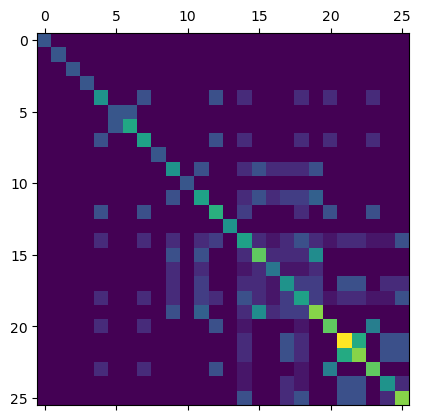

In [16]:
# plot a covariance matrix
# plt.matshow(uncertainty._get_intermediate_thermo_covariance_matrix())
plt.matshow(uncertainty.get_thermo_covariance_matrix())

# Manually check that overall uncertainty = sGs + sKs

## Grab sensitivities

In [17]:
reaction_system_index = 0
sens_species = sensitive_species[0]
csvfile_path = os.path.join(uncertainty.output_directory, 'solver',
                                        'sensitivity_{0}_SPC_{1}.csv'.format(reaction_system_index + 1,
                                                                             sens_species.index))
time, data_list = rmgpy.tools.plot.parse_csv_data(csvfile_path)

# compile a list of species and reaction sensitivities
# Note that most species/reactions won't meet the sensitivity threshold and thus won't be included in this list because they're functionally zero
# for uncorrelated analysis, the uncertainty assigned is the uncertainty value of the one parameter
# for correlated analysis, the uncertainty is a dictionary of partial derivatives:
# dG_i/dq for each parameter q that contributes to the uncertainty of G_i
# or dlnk_i/dq for each parameter q that contributes to the uncertainty of ln(k_i)
thermo_data_list = []
reaction_data_list = []
species_include_indices = []
reaction_include_indices = []
thermo_sensitivity_vector = np.zeros(len(uncertainty.species_list))
kinetics_sensitivity_vector = np.zeros(len(uncertainty.reaction_list))
for data in data_list:
    if data.species:
        for species in uncertainty.species_list:
            if species.to_chemkin() == data.species:
                index = uncertainty.species_list.index(species)
                species_include_indices.append(index)
                thermo_sensitivity_vector[index] = data.data[-1]
                break
        else:
            raise Exception('Chemkin name {} of species in the CSV file does not match anything in the '
                            'species list.'.format(data.species))

        data.uncertainty = uncertainty.thermo_input_intermediates[index]
        thermo_data_list.append(data)

    if data.reaction:
        rxn_index = int(data.index) - 1
        data.uncertainty = uncertainty.kinetic_input_intermediates[rxn_index]
        reaction_data_list.append(data)
        reaction_include_indices.append(rxn_index)
        kinetics_sensitivity_vector[rxn_index] = data.data[-1]

## Compute $\Sigma^G$ and $\Sigma^k$

In [18]:
Cov_G = uncertainty.get_thermo_covariance_matrix()
Cov_lnk = uncertainty.get_kinetic_covariance_matrix()

## Multiply to get total variance

In [19]:
total_var = np.dot(thermo_sensitivity_vector, np.dot(Cov_G, thermo_sensitivity_vector)) + \
            np.dot(kinetics_sensitivity_vector, np.dot(Cov_lnk, kinetics_sensitivity_vector))

In [20]:
total_var

0.7767151850403302

In [21]:
assert np.isclose(total_var, total_variance)
assert np.isclose(total_var, new_total_variance)

# Manually check that overall uncertainty = $s \frac{\partial G}{\partial q} \Sigma_{thermo}^q  \frac{\partial G}{\partial q} s +s \frac{\partial \ln k}{\partial q} \Sigma_{kinetic}^q  \frac{\partial \ln k}{\partial q} s $

### Compute  $\Sigma_{thermo}^q $ and $ \Sigma_{kinetic}^q$

In [22]:
# and go one level deeper and make sure it matches using the inner covariance
sigma_ww_thermo = uncertainty._get_intermediate_thermo_covariance_matrix()
sigma_ww_kinetics = uncertainty._get_intermediate_kinetics_covariance_matrix()

### Compute $\frac{\partial G}{\partial q}$ and $\frac{\partial \ln k}{\partial q}$

In [23]:
dGdq = uncertainty._get_dG_dq_matrix()
dlnkdq = uncertainty._get_dlnk_dq_matrix()

### Multiply together to get overall variance

In [24]:
var_thermo = np.dot(thermo_sensitivity_vector, np.dot(dGdq, np.dot(sigma_ww_thermo, np.dot(dGdq.T, thermo_sensitivity_vector))))
var_kinetic = np.dot(kinetics_sensitivity_vector, np.dot(dlnkdq, np.dot(sigma_ww_kinetics, np.dot(dlnkdq.T, kinetics_sensitivity_vector))))
total_var2 = var_thermo + var_kinetic
assert np.isclose(total_var2, total_variance)
assert np.isclose(total_var2, new_total_variance)

In [25]:
var_thermo

0.616311503811772

In [26]:
var_kinetic

0.16040368122855825